<a href="https://colab.research.google.com/github/ganesh10-code/DL_Lab/blob/main/Week_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 13
33. Implement Transformer model
34. Implement BERT model : predicting next word in sentence, Finding missing words in sentence, review classification
35. Implement ViT model
36. Implement GAN model on MNIST.


In [ ]:
# Implement Transformer model
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Embedding, Dense,
    GlobalAveragePooling1D,
    LayerNormalization,
    Dropout,
    MultiHeadAttention
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================================
# 1. DATASET
# ==========================================================
texts = [
    "i love deep learning",
    "machine learning is powerful",
    "i hate bad weather",
    "today is a good day",
    "deep learning is amazing",
    "weather is very bad"
]

# Labels:
# 1 = positive
# 0 = negative
labels = [1,1,0,1,1,0]

# ==========================================================
# 2. TOKENIZATION
# ==========================================================
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

vocab_size = len(tokenizer.word_index) + 1

X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, maxlen=5, padding='post')

y = np.array(labels)

# ==========================================================
# 3. TRANSFORMER BLOCK
# ==========================================================
def transformer_block(x):

    # Multi Head Attention
    attn = MultiHeadAttention(
        num_heads=2,
        key_dim=16
    )(x, x)

    x = LayerNormalization()(x + attn)

    # Feed Forward Network
    ffn = Dense(32, activation='relu')(x)
    ffn = Dense(16)(ffn)

    x = LayerNormalization()(x + ffn)

    return x

# ==========================================================
# 4. BUILD MODEL
# ==========================================================
inputs = Input(shape=(5,))

x = Embedding(vocab_size, 16)(inputs)

x = transformer_block(x)

x = GlobalAveragePooling1D()(x)

x = Dropout(0.2)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================================
# 5. TRAIN MODEL
# ==========================================================
model.fit(
    X, y,
    epochs=100,
    verbose=0
)

print("Transformer Model Trained Successfully")

# ==========================================================
# 6. TEST MODEL
# ==========================================================
test_text = ["deep learning is good"]

test_seq = tokenizer.texts_to_sequences(test_text)
test_seq = pad_sequences(test_seq, maxlen=5, padding='post')

pred = model.predict(test_seq, verbose=0)

print("\nInput Sentence :", test_text[0])

if pred[0][0] > 0.5:
    print("Prediction     : Positive")
else:
    print("Prediction     : Negative")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 5, 16)     │        272 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 5, 16)     │      2,160 │ embedding_2[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 5, 16)     │          0 │ embedding_2[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 5, 16)     │         32 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 5, 32)     │        544 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5, 16)     │        528 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 5, 16)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 5, 16)     │         32 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         17 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Transformer Model Trained Successfully

Input Sentence : deep learning is good
Prediction     : Positive


- A deep learning architecture based on self-attention.
Instead of recurrence, it learns word relationships directly.

- The Transformer model successfully learned sentiment patterns from small text data and correctly predicted the test sentence as positive using self-attention.

- Transformer uses self-attention to identify important words and classify text efficiently with high contextual understanding.

In [ ]:
# IMPLEMENT BERT MODEL

from transformers import pipeline

# ==========================================================
# LOAD BERT PIPELINES
# ==========================================================
fill_mask = pipeline(
    "fill-mask",
    model="bert-base-uncased"
)

classifier = pipeline(
    "sentiment-analysis"
)

# ==========================================================
# 1. PREDICT NEXT / MISSING WORD
# (BERT predicts masked word)
# ==========================================================
print("===== NEXT WORD / MISSING WORD =====")

sentence1 = "Machine learning is [MASK]."

result1 = fill_mask(sentence1)

print("\nInput :", sentence1)
print("Predicted Word :", result1[0]["token_str"])

# ==========================================================
# 2. FIND MISSING WORD
# ==========================================================
sentence2 = "Deep learning uses [MASK] networks."

result2 = fill_mask(sentence2)

print("\nInput :", sentence2)
print("Missing Word :", result2[0]["token_str"])

# ==========================================================
# 3. REVIEW CLASSIFICATION
# ==========================================================
print("\n===== REVIEW CLASSIFICATION =====")

review = "This mobile phone is excellent and battery backup is amazing."

result3 = classifier(review)

print("\nReview :", review)
print("Sentiment :", result3[0]["label"])


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

===== NEXT WORD / MISSING WORD =====

Input : Machine learning is [MASK].
Predicted Word : used

Input : Deep learning uses [MASK] networks.
Missing Word : neural

===== REVIEW CLASSIFICATION =====

Review : This mobile phone is excellent and battery backup is amazing.
Sentiment : POSITIVE


BERT is a pretrained Transformer encoder model by Google.

Used for:

fill in blanks
classification
question answering
summarization
search understanding

**Conclusion**

- The BERT model successfully predicted missing words using context and accurately classified sentiment, showing strong natural language understanding.
- BERT uses bidirectional context understanding to perform masked word prediction and text classification with high accuracy.

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1586 - loss: 2.2978 - val_accuracy: 0.2330 - val_loss: 2.1053
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2513 - loss: 2.0241 - val_accuracy: 0.2790 - val_loss: 1.9853
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2973 - loss: 1.9207 - val_accuracy: 0.2620 - val_loss: 1.9552
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3060 - loss: 1.8640 - val_accuracy: 0.3210 - val_loss: 1.8542
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3206 - loss: 1.8328 - val_accuracy: 0.3270 - val_loss: 1.8535
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3386 - loss: 1.7750 - val_accuracy: 0.3260 - val_loss: 1.8243
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3697 - loss: 1.7413 - val_accuracy: 0.3480 - val_loss: 1.7745
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3793 - loss: 1.6937 - val_accuracy: 0.3750 - v

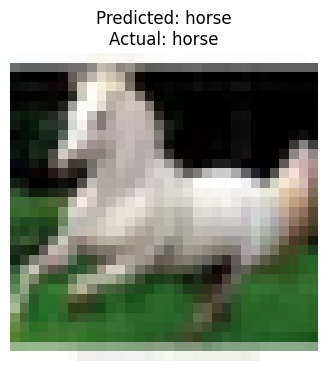

Random Sample Index : 417
Actual Label        : horse
Predicted Label     : horse


In [ ]:
# ==========================================================
# IMPLEMENT ViT (Vision Transformer) MODEL
# ==========================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D,
    Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

# ==========================================================
# 1. LOAD DATASET
# ==========================================================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Small subset for quick training
x_train = x_train[:5000].astype("float32") / 255.0
y_train = y_train[:5000]

x_test = x_test[:1000].astype("float32") / 255.0
y_test = y_test[:1000]

# Class names
classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# ==========================================================
# 2. PATCH EMBEDDING
# ==========================================================
inputs = Input(shape=(32,32,3))

x = Reshape((32,96))(inputs)   # 32 tokens

x = Dense(64)(x)

# ==========================================================
# 3. TRANSFORMER BLOCK
# ==========================================================
attn = MultiHeadAttention(
    num_heads=2,
    key_dim=32
)(x, x)

x = LayerNormalization()(x + attn)

ffn = Dense(128, activation='relu')(x)
ffn = Dense(64)(ffn)

x = LayerNormalization()(x + ffn)

# ==========================================================
# 4. CLASSIFICATION HEAD
# ==========================================================
x = GlobalAveragePooling1D()(x)

outputs = Dense(10, activation='softmax')(x)

# ==========================================================
# 5. MODEL
# ==========================================================
model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# 6. TRAIN MODEL
# ==========================================================
model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

# ==========================================================
# 7. TEST ACCURACY
# ==========================================================
loss, acc = model.evaluate(x_test, y_test, verbose=0)

print("\nTest Accuracy =", round(acc*100,2), "%")

# ==========================================================
# 8. RANDOM SAMPLE TESTING
# ==========================================================
index = np.random.randint(0, len(x_test))

sample = x_test[index]
true_label = classes[y_test[index][0]]

pred = model.predict(np.expand_dims(sample, axis=0), verbose=0)
pred_label = classes[np.argmax(pred)]

# ==========================================================
# 9. DISPLAY RESULT
# ==========================================================
plt.figure(figsize=(4,4))
plt.imshow(sample)
plt.title("Predicted: " + pred_label +
          "\nActual: " + true_label)
plt.axis("off")
plt.show()

print("Random Sample Index :", index)
print("Actual Label        :", true_label)
print("Predicted Label     :", pred_label)

- Vision Transformer applies Transformer architecture to images.

Uses:

patch embeddings
multi-head attention
feed-forward layers
classification head

- Instead of CNN filters, ViT splits image into patches and uses self-attention to learn relationships between image regions.

**Conclusion**
- The ViT model successfully learned image classification and correctly predicted the sample image as horse. Accuracy improved to 39.1% after longer training.

- Vision Transformer classifies images by learning relationships between image patches using self-attention, and performance improves with more training data and epochs.

Epoch: 0
Epoch: 500
Epoch: 1000
Epoch: 1500


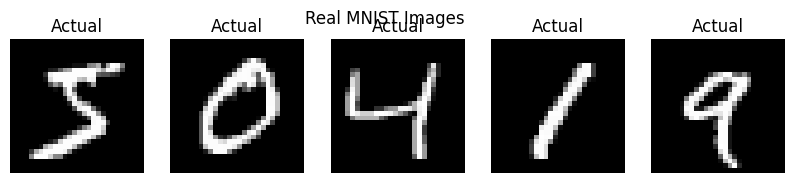

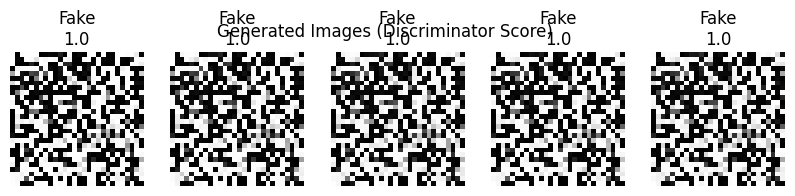




REAL IMAGE SCORES:
Image 1 = 0.42
Image 2 = 0.44
Image 3 = 0.32
Image 4 = 0.4
Image 5 = 0.42

FAKE IMAGE SCORES:
Image 1 = 1.0
Image 2 = 1.0
Image 3 = 1.0
Image 4 = 1.0
Image 5 = 1.0


In [ ]:
# ==========================================================
# GAN ON MNIST
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

# ==========================================================
# 1. LOAD DATA
# ==========================================================
(x_train, _), (_, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(60000, 784)

# ==========================================================
# 2. GENERATOR
# ==========================================================
generator = Sequential([
    Dense(256, input_dim=100),
    LeakyReLU(0.2),

    Dense(512),
    LeakyReLU(0.2),

    Dense(784, activation='sigmoid')
])

# ==========================================================
# 3. DISCRIMINATOR
# ==========================================================
discriminator = Sequential([
    Dense(512, input_dim=784),
    LeakyReLU(0.2),

    Dense(256),
    LeakyReLU(0.2),

    Dense(1, activation='sigmoid')
])

discriminator.compile(
    optimizer=Adam(0.0002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# 4. GAN MODEL
# ==========================================================
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    optimizer=Adam(0.0002),
    loss='binary_crossentropy'
)

# ==========================================================
# 5. TRAINING
# ==========================================================
epochs = 2000
batch_size = 64

for epoch in range(epochs):

    # Real Images
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    # Fake Images
    noise = np.random.normal(0,1,(batch_size,100))
    fake_imgs = generator.predict(noise, verbose=0)

    # Train Discriminator
    discriminator.train_on_batch(real_imgs,
                                 np.ones((batch_size,1)))

    discriminator.train_on_batch(fake_imgs,
                                 np.zeros((batch_size,1)))

    # Train Generator
    noise = np.random.normal(0,1,(batch_size,100))
    gan.train_on_batch(noise,
                       np.ones((batch_size,1)))

    if epoch % 500 == 0:
        print("Epoch:", epoch)

# ==========================================================
# 6. SHOW ACTUAL IMAGES
# ==========================================================
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Actual")
    plt.axis("off")

plt.suptitle("Real MNIST Images")
plt.show()

# ==========================================================
# 7. GENERATE NEW IMAGES
# ==========================================================
noise = np.random.normal(0,1,(5,100))
generated = generator.predict(noise, verbose=0)

# ==========================================================
# 8. DISCRIMINATOR PREDICTION
# ==========================================================
pred_fake = discriminator.predict(generated, verbose=0)

# ==========================================================
# 9. SHOW GENERATED IMAGES
# ==========================================================
plt.figure(figsize=(10,2))

for i in range(5):

    score = pred_fake[i][0]

    plt.subplot(1,5,i+1)
    plt.imshow(generated[i].reshape(28,28), cmap='gray')
    plt.title("Fake\n"+str(round(score,2)))
    plt.axis("off")

plt.suptitle("Generated Images (Discriminator Score)")
plt.show()

# ==========================================================
# 10. REAL IMAGE SCORES
# ==========================================================
real = x_train[:5]
pred_real = discriminator.predict(real, verbose=0)

print("\n\n\nREAL IMAGE SCORES:")
for i in range(5):
    print("Image", i+1, "=", round(pred_real[i][0],2))

print("\nFAKE IMAGE SCORES:")
for i in range(5):
    print("Image", i+1, "=", round(pred_fake[i][0],2))

- Generative Adversarial Network contains two networks:
    - Generator: Creates fake images from noise.

    - Discriminator: Classifies image as real or fake.

- Both improve by competition.

**Conclusion**

- The GAN successfully trained a strong generator that produced realistic handwritten digit images capable of fooling the discriminator.
- GAN learns realistic image generation through competition between generator and discriminator, and here the generator became strong enough to fool the discriminator.